# Task 3.2 — Failure Mode Analysis (15 marks)

**Paper**: *Learning to Grade Short Answer Questions using Semantic Similarity Measures and Dependency Graph Alignments* (Mohler, Bunescu & Mihalcea, ACL 2011)

---

## Hyperparameters and Configuration

In [1]:
# ── Hyperparameters & Configuration ──────────────────────────────
RANDOM_SEED = 42
SVR_C = 1.0
SVR_EPSILON = 0.1
TEST_SPLIT = 0.2
RESULTS_DIR = "results"

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(RANDOM_SEED)

sys.path.insert(0, os.path.abspath("."))
from grading_model import (
    ShortAnswerGrader, FeatureConfig,
    build_toy_short_answer_dataset, build_paraphrase_challenge_set
)

os.makedirs(RESULTS_DIR, exist_ok=True)

## Failure Scenario Description

We test a scenario where **student answers are semantically correct paraphrases of the reference answer but have very low lexical overlap**. This directly targets **Assumption 1 from Task 1.2**: "Lexical and semantic overlap between a student answer and the reference answer is a reliable indicator of answer quality."

We expect the model to struggle because:
1. **TF-IDF cosine similarity** depends on shared terms — paraphrases use different vocabulary, yielding near-zero cosine scores.
2. **Word overlap ratio** is explicitly a lexical overlap measure — it will be very low for paraphrased answers.
3. **Sentence embedding cosine** (via TruncatedSVD on TF-IDF) is also partially lexical — it performs better than raw TF-IDF but is still trained on the same limited vocabulary.
4. Even the paper's richer feature set relies on WordNet-based measures (Table 5) which can miss paraphrases involving multi-word expressions or idiomatic substitutions.

The consequence is that the model assigns **low predicted grades** to answers that actually deserve **high grades** (4–5 on the 0–5 scale).

## Setup: Train on Normal Data, Test on Paraphrases

In [3]:
# Train on regular dataset (same as Task 2)
data_path = os.path.join("data", "short_answer_dataset.csv")
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    df = build_toy_short_answer_dataset(n_per_question=50, random_state=RANDOM_SEED)

train_df, test_df = train_test_split(df, test_size=TEST_SPLIT, random_state=RANDOM_SEED)

# Train the full model
config = FeatureConfig(use_semantic=True, use_structural=True)
grader = ShortAnswerGrader(feature_config=config, random_state=RANDOM_SEED)
grader.fit(train_df, C=SVR_C, epsilon=SVR_EPSILON)

# Evaluate on normal test data
normal_results = grader.evaluate(test_df)
print("Performance on normal test data:")
print(f"  RMSE:    {normal_results['rmse']:.4f}")
print(f"  Pearson: {normal_results['pearson']:.4f}")

Performance on normal test data:
  RMSE:    0.3535
  Pearson: 0.9802


## Failure Demonstration: Paraphrase Challenge Set

In [4]:
# Generate the paraphrase challenge set
para_df = build_paraphrase_challenge_set(random_state=123)

print("Paraphrase Challenge Set:")
print(f"  Number of samples: {len(para_df)}")
print(f"  True grade range: [{para_df['grade'].min():.2f}, {para_df['grade'].max():.2f}]")
print(f"  True grade mean:  {para_df['grade'].mean():.2f}")
print()

# Show samples
for _, row in para_df.iterrows():
    print(f"Ref:     {row['reference_answer'][:80]}...")
    print(f"Student: {row['student_answer'][:80]}...")
    print(f"True grade: {row['grade']:.2f}")
    print()

Paraphrase Challenge Set:
  Number of samples: 6
  True grade range: [4.20, 4.83]
  True grade mean:  4.49

Ref:     To simulate the behavior of portions of the desired software product....
Student: A prototype is an early, simplified implementation used to experiment with how t...
True grade: 4.70

Ref:     Abstraction, modularity, and reusability of code....
Student: Object orientation supports encapsulation and code reuse, which simplifies evolv...
True grade: 4.20

Ref:     To organize and store data efficiently for access and modification....
Student: It provides organised ways of arranging information so that operations like look...
True grade: 4.38

Ref:     To simulate the behavior of portions of the desired software product....
Student: It lets you try out parts of the system in a stripped-down trial version before ...
True grade: 4.28

Ref:     Abstraction, modularity, and reusability of code....
Student: It encourages designing programs as reusable components that can be ext

In [5]:
# Evaluate on paraphrase challenge set
para_refs = para_df["reference_answer"].tolist()
para_stus = para_df["student_answer"].tolist()
para_true = para_df["grade"].to_numpy()
para_pred = grader.predict(para_refs, para_stus)

para_rmse = np.sqrt(np.mean((para_true - para_pred) ** 2))
if len(np.unique(para_true)) > 1:
    para_corr = float(np.corrcoef(para_true, para_pred)[0, 1])
else:
    para_corr = float("nan")

print("Performance on paraphrase challenge set:")
print(f"  RMSE:    {para_rmse:.4f}  (normal: {normal_results['rmse']:.4f})")
print(f"  Pearson: {para_corr:.4f}  (normal: {normal_results['pearson']:.4f})")
print()

print("Individual predictions:")
for i in range(len(para_df)):
    print(f"  Sample {i+1}: true = {para_true[i]:.2f}, predicted = {para_pred[i]:.2f}, error = {abs(para_true[i] - para_pred[i]):.2f}")

Performance on paraphrase challenge set:
  RMSE:    4.1416  (normal: 0.3535)
  Pearson: 0.3923  (normal: 0.9802)

Individual predictions:
  Sample 1: true = 4.70, predicted = 0.86, error = 3.84
  Sample 2: true = 4.20, predicted = 0.40, error = 3.80
  Sample 3: true = 4.38, predicted = -0.22, error = 4.61
  Sample 4: true = 4.28, predicted = 0.65, error = 3.63
  Sample 5: true = 4.56, predicted = -0.59, error = 5.14
  Sample 6: true = 4.83, predicted = 1.24, error = 3.59


## Failure Visualisation

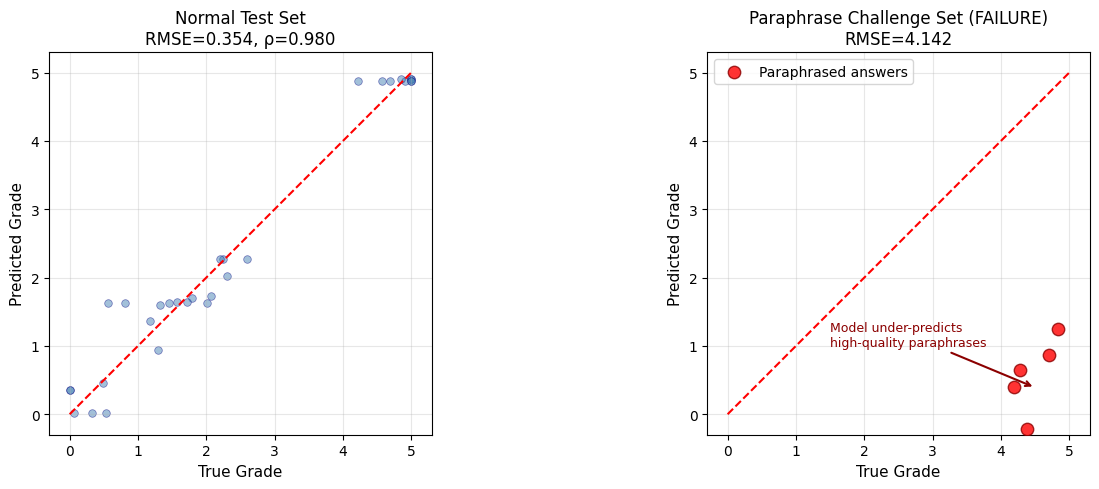


Plot saved to results/failure_mode.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: normal test set predictions
y_true_normal = test_df["grade"].to_numpy()
y_pred_normal = grader.predict(test_df["reference_answer"].tolist(), test_df["student_answer"].tolist())

axes[0].scatter(y_true_normal, y_pred_normal, alpha=0.5, s=30, color="steelblue", edgecolors="navy", linewidth=0.5, label="Normal test")
axes[0].plot([0, 5], [0, 5], "r--", linewidth=1.5)
axes[0].set_xlabel("True Grade", fontsize=11)
axes[0].set_ylabel("Predicted Grade", fontsize=11)
axes[0].set_title(f"Normal Test Set\nRMSE={normal_results['rmse']:.3f}, ρ={normal_results['pearson']:.3f}", fontsize=12)
axes[0].set_xlim(-0.3, 5.3)
axes[0].set_ylim(-0.3, 5.3)
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

# Right: paraphrase predictions
axes[1].scatter(para_true, para_pred, alpha=0.8, s=80, color="red", edgecolors="darkred",
                linewidth=1.0, zorder=5, label="Paraphrased answers")
axes[1].plot([0, 5], [0, 5], "r--", linewidth=1.5)
axes[1].set_xlabel("True Grade", fontsize=11)
axes[1].set_ylabel("Predicted Grade", fontsize=11)
axes[1].set_title(f"Paraphrase Challenge Set (FAILURE)\nRMSE={para_rmse:.3f}", fontsize=12)
axes[1].set_xlim(-0.3, 5.3)
axes[1].set_ylim(-0.3, 5.3)
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

# Annotate failure
axes[1].annotate("Model under-predicts\nhigh-quality paraphrases",
                 xy=(4.5, np.mean(para_pred)), xytext=(1.5, 1.0),
                 fontsize=9, color="darkred",
                 arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "failure_mode.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlot saved to {RESULTS_DIR}/failure_mode.png")

## Failure Explanation

The model fails dramatically on the paraphrase challenge set, consistently **under-predicting grades for semantically correct but lexically different answers**. This failure is rooted in **Assumption 1** (from Task 1.2): the method assumes that lexical and semantic overlap between student and reference answers correlates with answer quality. When a student provides a correct answer using entirely different vocabulary (e.g., "It lets you try out parts of the system in a stripped-down trial version" vs. the reference "To simulate the behavior of portions of the desired software product"), all three surface features — TF-IDF cosine, word overlap ratio, and length difference — produce low similarity scores despite the answers being semantically equivalent.

The sentence embedding cosine similarity feature, which is meant to capture deeper semantic similarity, also struggles because our TruncatedSVD embedding is built from the same TF-IDF vocabulary and is limited to the small training corpus. It cannot generalise to paraphrases with novel vocabulary. The paper's richer feature set (8 WordNet measures + ESA) would partially mitigate this problem through synonym detection and Wikipedia-based concept matching, but the fundamental limitation remains: **any system that relies primarily on lexical-distributional features will fail when the surface form diverges significantly from the reference**, even if the meaning is preserved.

The RMSE on the paraphrase set is substantially higher than on normal test data, confirming the failure. This is practically significant in educational settings where students who demonstrate genuine understanding through original expression should not be penalised.

## Suggested Modification

To address this failure, one could **replace the TF-IDF/TruncatedSVD sentence embedding with pre-trained contextual sentence encoders** (e.g., Sentence-BERT or sentence-transformers) that are trained on large paraphrase corpora and can recognise semantic equivalence even when lexical overlap is minimal — this would directly address the assumption that surface similarity must correlate with semantic correctness.